In [1]:
import napari
import numpy as np
from aicsimageio import AICSImage

import pandas as pd
from skimage import measure


import tifffile as tf
import matplotlib.pyplot as plt
import xarray as xr
from tifffile import tifffile
import tifftools
import os
from matplotlib import pyplot as plt
from os.path import sep
from skimage import io
from PIL import Image
import imageio


from skimage.measure import regionprops_table

import seaborn as sns

import czifile

import math

from pathlib import Path
import re

from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit

from matplotlib.patches import Patch



/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/pydantic/_migration.py:283: UserWarning: `pydantic.error_wrappers:ValidationError` has been moved to `pydantic:ValidationError`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


please read this part before combining the L1L9 and R1R9 side of the 3glo brains into the analysis:

if combine 1 and 9 glomeruli by adding and then averaging, then BE CAUTIOUS when brining these sides into the total analysis:
1. summing all the columns is not good (missing the last glomerulus)!
2. if need to take average, remember don't divide the sum by how many df comes to do the sum because for the columns that add the "last glomerulus" the denominator is still gonna count the df that this "last glomerulus" comes from!

<font size="7">PART ONE</font>

import all the df and input the subtype for each fly*

In [2]:
glomeruli = ["L9","L8","L7","L6","L5","L4","L3","L2","L1",
             "R1","R2","R3","R4","R5","R6","R7","R8","R9"]

In [ ]:
files = {
    "fly1": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly1.csv",
    "fly2": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly2.csv",
    "fly3": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly3.csv",
    #"fly100": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly?.csv"         # this is the one fixed with ethanol so bad quality.
    "fly4": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly4.csv",
    "fly5": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly5.csv",           # this one tdt very dim and blur. ALSO, the mean_green and mean_red for L9,L8,R9 is NOT useable!!!
    "fly6": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly6.csv",
    "fly7": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly7.csv",
}

In [31]:
# my mac laptop
files = {
    "fly1": "/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/mean signal value csv-25summer/fly1.csv",
    "fly2": "/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/mean signal value csv-25summer/fly2.csv",
    "fly3": "/Users/sansachen/Desktop/fisherlab/github-works/connectome_analysis_fisherlab/mean signal value csv-25summer/fly3.csv"
    #"fly100": "/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/mean signal value csv-25summer/fly?.csv"         # this is the one fixed with ethanol so bad quality.
}

In [4]:
original = {
    name: pd.read_csv(path, index_col=0).assign(glomerulus=glomeruli)[
        ["glomerulus","mean_red","mean_green","total_red","total_green"]
    ]
    for name, path in files.items()
}

In [65]:
# another (previous) way to open all cvs one by one
'''
fly1 = pd.read_csv("/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/single cell fly csv/fly1.csv", index_col=0).assign(glomerulus=glomeruli)[["glomerulus","mean_red","mean_green","total_red","total_green"]]
fly2 = pd.read_csv("/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/single cell fly csv/fly2.csv", index_col=0).assign(glomerulus=glomeruli)[["glomerulus","mean_red","mean_green","total_red","total_green"]]
'''


'\nfly1 = pd.read_csv("/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/single cell fly csv/fly1.csv", index_col=0).assign(glomerulus=glomeruli)[["glomerulus","mean_red","mean_green","total_red","total_green"]]\nfly2 = pd.read_csv("/Users/fisherguest/Documents/Projects/connectome_analysis_fisherlab/single cell fly csv/fly2.csv", index_col=0).assign(glomerulus=glomeruli)[["glomerulus","mean_red","mean_green","total_red","total_green"]]\n'

In [5]:
fly_subtype = pd.DataFrame({
    'fly': ['fly1','fly2','fly3','fly4','fly5','fly6','fly7'],
    'subtype': ['L3R6','L4R5','L2R7','L5R4','L8R1R9','L1L9R8','L3R6']
})

In [6]:
# these codes can handle 2 3glo situation.

tokens = fly_subtype['subtype'].str.findall(r'[LR]\d+')

# 2. Figure out the maximum number of tokens any row has
max_parts = tokens.map(len).max()

# 3. Create column names dynamically (part1, part2, …)
col_names = [f'part{i+1}' for i in range(max_parts)]

# 4. “Unpack” the lists of tokens into separate columns
fly_subtype[col_names] = pd.DataFrame(tokens.tolist(), index=fly_subtype.index)

fly_subtype

,fly,subtype,part1,part2,part3
0,fly1,L3R6,L3,R6,None
1,fly2,L4R5,L4,R5,None
2,fly3,L2R7,L2,R7,None
3,fly4,L5R4,L5,R4,None
4,fly5,L8R1R9,L8,R1,R9
5,fly6,L1L9R8,L1,L9,R8
6,fly7,L3R6,L3,R6,None


<font size="7">PART TWO</font>

1. separate L1L9R8 and L8R1R9 from the rest by putting those fly* into a dict [brains_with_3glo] and the rest normal 2glo fly* into [brains_with_2glo].
2. split each fly* into its left and right side **while** reordering the rows so the axon glomerulus is in the center (indexed 4): NOTE, the L1L9/R1R9 side of 3glo fly* always has L1/R1 in the 4-index row.
3. put all the sides (halves) into one dict [reordered_halves_all] to make bar graphs.

In [7]:
brains_with_3glo = {}
brains_with_2glo = {}

for _, row in fly_subtype.iterrows():
    fly_name = row["fly"]
    subtype  = row["subtype"]

    if len(subtype) == 4:
        brains_with_2glo[fly_name] = original[fly_name]
    else:
        brains_with_3glo[fly_name] = original[fly_name]

# to check
list(brains_with_3glo.keys())
#list(brains_with_2glo.keys())

['fly5', 'fly6']

In [8]:
list(brains_with_2glo.keys())

['fly1', 'fly2', 'fly3', 'fly4', 'fly7']

In [9]:
def split_halves(source_dict):
    halves = {}
    for name, df in source_dict.items():
        df_first  = df.iloc[:9].reset_index(drop=True)
        df_second = df.iloc[9:].reset_index(drop=True)
        halves[f"{name}_L"] = df_first
        halves[f"{name}_R"] = df_second
    return halves

brains_with_2glo_halves = split_halves(brains_with_2glo)
brains_with_3glo_halves = split_halves(brains_with_3glo)

In [10]:
list(brains_with_3glo_halves.keys())

['fly5_L', 'fly5_R', 'fly6_L', 'fly6_R']

In [11]:
list(brains_with_2glo_halves.keys())

['fly1_L',
 'fly1_R',
 'fly2_L',
 'fly2_R',
 'fly3_L',
 'fly3_R',
 'fly4_L',
 'fly4_R',
 'fly7_L',
 'fly7_R']

In [12]:
brains_with_2glo_halves['fly1_L']

,glomerulus,mean_red,mean_green,total_red,total_green
0,L9,848.954201,73.941009,4.022761e+08,35036873.0
1,L8,955.666263,71.846106,6.839656e+08,51419899.0
2,L7,846.518062,63.483875,5.785502e+08,43387864.0
3,L6,888.429529,59.067325,3.275302e+08,21775878.0
4,L5,849.205255,61.282188,3.313701e+08,23913045.0
5,L4,769.550523,56.653493,2.707810e+08,19934608.0
6,L3,1429.598217,80.145079,2.727652e+09,152915609.0
7,L2,615.791312,45.274323,2.307241e+08,16963338.0
8,L1,723.791525,54.077473,4.096240e+08,30604713.0


In [13]:
# split left and right bridge for 2glo brains:

parts_lookup = fly_subtype.set_index("fly")[["part1", "part2"]].to_dict("index")

reordered_2glo_halves = {}

for name, df in brains_with_2glo_halves.items():
    base_name = name.split("_")[0]                   # e.g., "fly1_L" -> "fly1"
    column_to_look = "part1" if "_L" in name else "part2"

    parts = parts_lookup.get(base_name)
    if parts is None or pd.isna(parts.get(column_to_look, None)):
        continue

    center = parts[column_to_look]                   # e.g., "R4" or "L3"

    # find the row index where glomerulus == center
    idxs = df.index[df["glomerulus"] == center]
    if len(idxs) == 0:
        continue
    current_idx = int(idxs[0])

    # put center on the 5th row (0-based index 4)
    target_idx = 4
    shift = target_idx - current_idx

    # roll row order safely
    order = np.roll(np.arange(len(df)), shift)
    df_reordered = df.iloc[order].reset_index(drop=True)

    reordered_2glo_halves[f"{name}_reordered"] = df_reordered


In [14]:
reordered_2glo_halves['fly1_L_reordered']

,glomerulus,mean_red,mean_green,total_red,total_green
0,L7,846.518062,63.483875,5.785502e+08,43387864.0
1,L6,888.429529,59.067325,3.275302e+08,21775878.0
2,L5,849.205255,61.282188,3.313701e+08,23913045.0
3,L4,769.550523,56.653493,2.707810e+08,19934608.0
4,L3,1429.598217,80.145079,2.727652e+09,152915609.0
5,L2,615.791312,45.274323,2.307241e+08,16963338.0
6,L1,723.791525,54.077473,4.096240e+08,30604713.0
7,L9,848.954201,73.941009,4.022761e+08,35036873.0
8,L8,955.666263,71.846106,6.839656e+08,51419899.0


In [17]:
parts_lookup = fly_subtype.set_index("fly")[["part1", "part2", "part3"]].to_dict("index")

reordered_3glo_halves = {}

for name, df in brains_with_3glo_halves.items():
    # parse "<fly>_<side>" robustly (handles extra suffixes like _reordered)
    m = re.match(r'^(.+?)_([LR])(?:_.*)?$', name, flags=re.IGNORECASE)
    if not m:
        continue
    fly_base, side = m.group(1), m.group(2).upper()

    parts = parts_lookup.get(fly_base)
    if parts is None:
        continue

    raw_parts = [parts.get("part1"), parts.get("part2"), parts.get("part3")]
    centers = []
    for p in raw_parts:
        if isinstance(p, str):
            s = p.strip()
            if s and s.lower() != "none" and s.upper().startswith(side):
                centers.append(s.upper())  # normalize

    if not centers:
        continue

    n = len(df)
    gloms_upper = df["glomerulus"].astype(str).str.upper()

    # ---------- SPECIAL PAIR RULE ----------
    # L halves: place L1@4, L9@5
    # R halves: place R9@4, R1@5  (your corrected requirement)
    if side == "L":
        primary, secondary = "L1", "L9"
    else:  # side == "R"
        primary, secondary = "R9", "R1"

    pair = {primary, secondary}
    if pair.issubset(set(centers)):
        # 1) roll so that PRIMARY lands at index 4
        idx_primary = np.where(gloms_upper.values == primary)[0]
        if idx_primary.size:
            shift = 4 - int(idx_primary[0])
            order = np.roll(np.arange(n), shift)
            df_roll = df.iloc[order].reset_index(drop=True)
            gloms_roll_upper = df_roll["glomerulus"].astype(str).str.upper()

            # 2) move SECONDARY to index 5 (preserving others)
            pos_sec = np.where(gloms_roll_upper.values == secondary)[0]
            if pos_sec.size:
                pos_sec = int(pos_sec[0])
                if pos_sec != 5:
                    perm = list(range(n))
                    perm.pop(pos_sec)          # remove current position
                    perm.insert(5, pos_sec)    # insert at 5
                    df_roll = df_roll.iloc[perm].reset_index(drop=True)

            reordered_3glo_halves[f"{name}_reordered"] = df_roll
            continue
        # if somehow primary missing in this half, fall through to default

    # ---------- DEFAULT (single center or other combos) ----------
    # Preference: for L → L1 then L9; for R → R9 then R1 (to match your R preference)
    prefs = [("L1", "L9"), ("R9", "R1")][side == "R"]
    preferred = next((p for p in prefs if p in centers), centers[0])

    idxs = np.where(gloms_upper.values == preferred)[0]
    if idxs.size == 0:
        continue

    target_idx = 4
    shift = target_idx - int(idxs[0])
    order = np.roll(np.arange(n), shift)
    df_reordered = df.iloc[order].reset_index(drop=True)

    reordered_3glo_halves[f"{name}_reordered"] = df_reordered

In [20]:
reordered_3glo_halves['fly6_L_reordered']

,glomerulus,mean_red,mean_green,total_red,total_green
0,L5,582.474425,159.246668,9.140422e+08,249896241.0
1,L4,431.326973,152.045308,5.514071e+08,194374265.0
2,L3,360.642758,134.124884,3.887624e+08,144582735.0
3,L2,312.708269,104.127724,3.294169e+08,109691477.0
4,L1,811.562076,143.245844,1.511680e+09,266821168.0
5,L9,979.079773,203.910521,1.399893e+09,291552283.0
6,L8,463.568323,161.377641,7.504833e+08,261258620.0
7,L7,568.878374,167.711272,1.014467e+09,299075486.0
8,L6,423.130145,143.014581,4.827564e+08,163167767.0


In [21]:
reordered_3glo_halves['fly5_R_reordered']

,glomerulus,mean_red,mean_green,total_red,total_green
0,R5,141.105013,26.666706,268482061,50739034
1,R6,153.156412,29.188990,176626254,33661940
2,R7,205.923968,35.560629,311569965,53804440
3,R8,146.704492,36.782444,278433829,69810246
4,R9,239.888989,40.622732,535220205,97960443
5,R1,234.183041,26.001336,662037565,73506012
6,R2,105.323247,21.642499,128691526,26444363
7,R3,106.027822,23.489537,123137319,27279997
8,R4,126.859500,24.551414,205863156,39841176


In [22]:
# maybe combine reordered_2glo_halves and reordered_3glo_halves into a reordered_dfs
reordered_halves_all = {**reordered_2glo_halves, **reordered_3glo_halves}
list(reordered_halves_all.keys())

['fly1_L_reordered',
 'fly1_R_reordered',
 'fly2_L_reordered',
 'fly2_R_reordered',
 'fly3_L_reordered',
 'fly3_R_reordered',
 'fly4_L_reordered',
 'fly4_R_reordered',
 'fly7_L_reordered',
 'fly7_R_reordered',
 'fly5_L_reordered',
 'fly5_R_reordered',
 'fly6_L_reordered',
 'fly6_R_reordered']

In [24]:
reordered_halves_all['fly5_R_reordered']

,glomerulus,mean_red,mean_green,total_red,total_green
0,R5,141.105013,26.666706,268482061,50739034
1,R6,153.156412,29.188990,176626254,33661940
2,R7,205.923968,35.560629,311569965,53804440
3,R8,146.704492,36.782444,278433829,69810246
4,R9,239.888989,40.622732,535220205,97960443
5,R1,234.183041,26.001336,662037565,73506012
6,R2,105.323247,21.642499,128691526,26444363
7,R3,106.027822,23.489537,123137319,27279997
8,R4,126.859500,24.551414,205863156,39841176


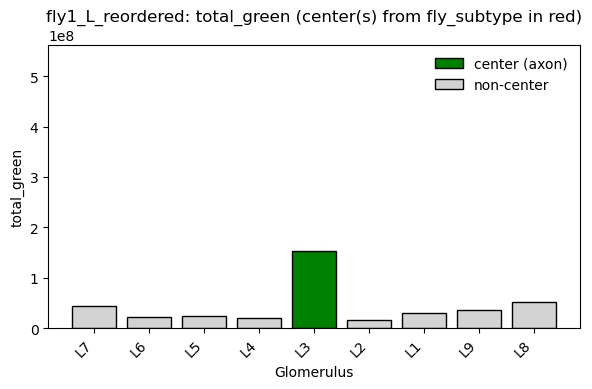

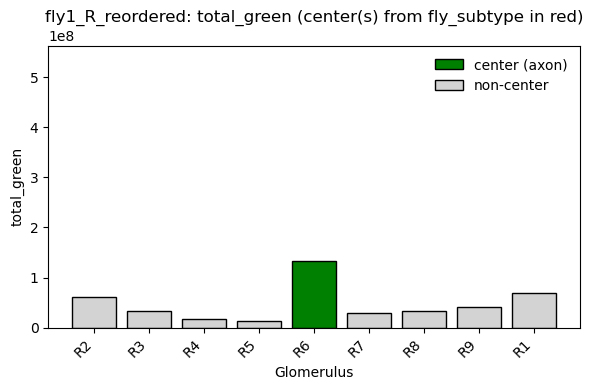

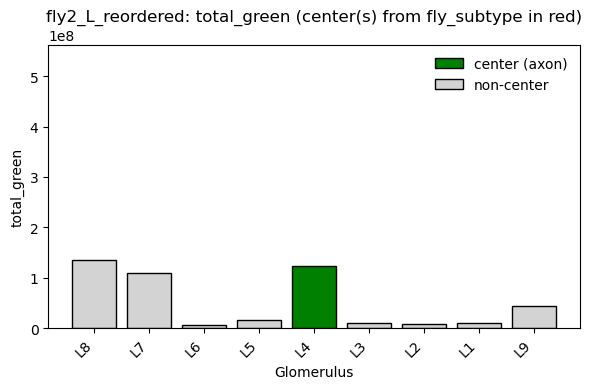

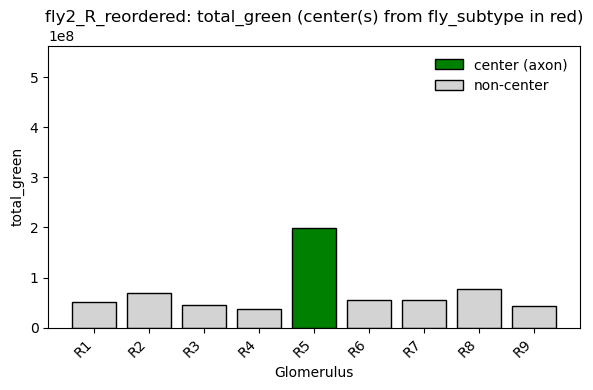

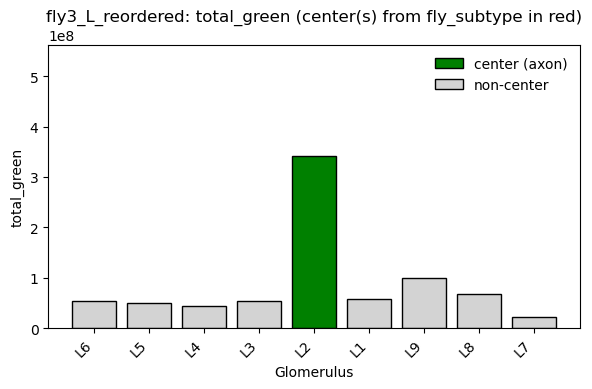

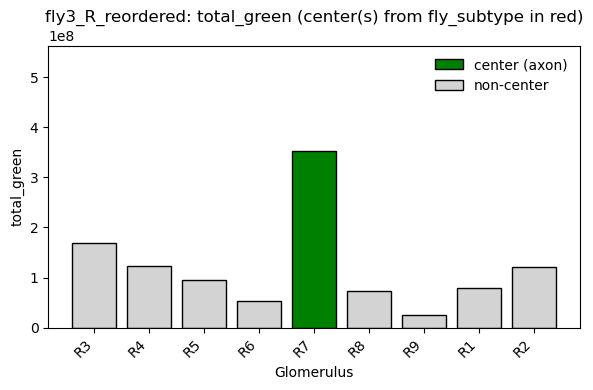

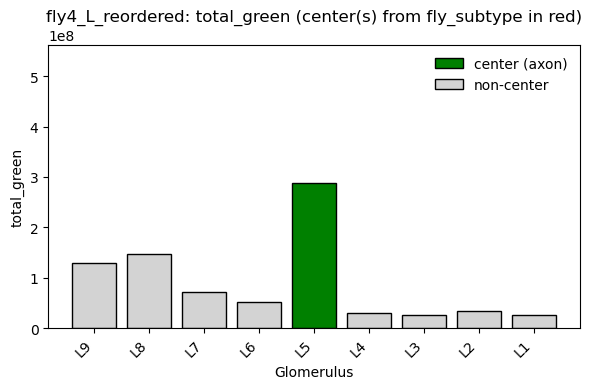

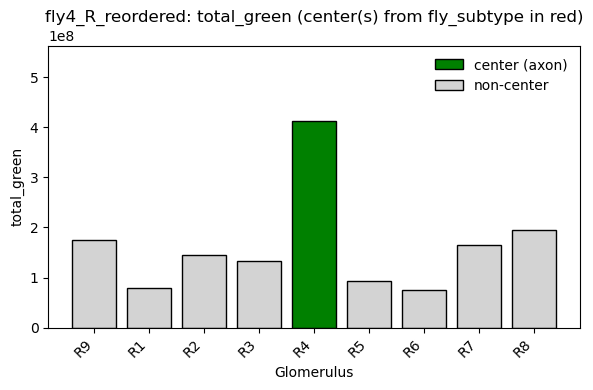

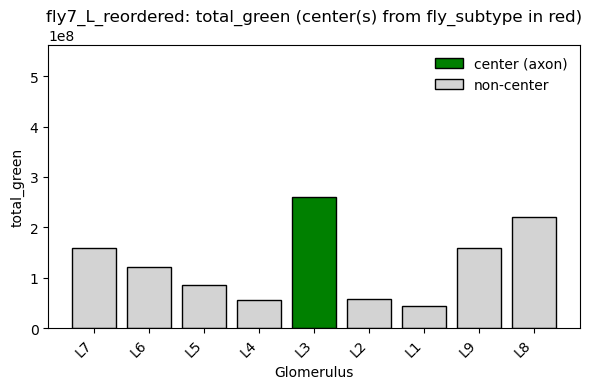

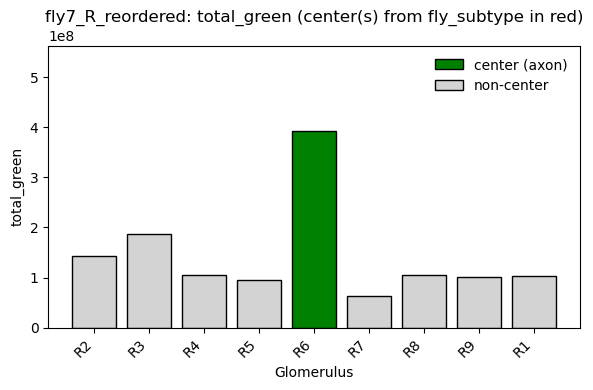

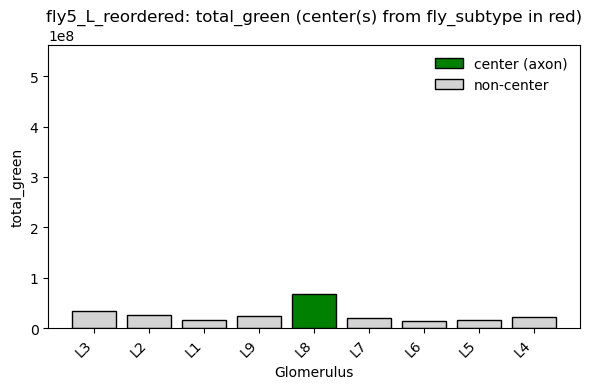

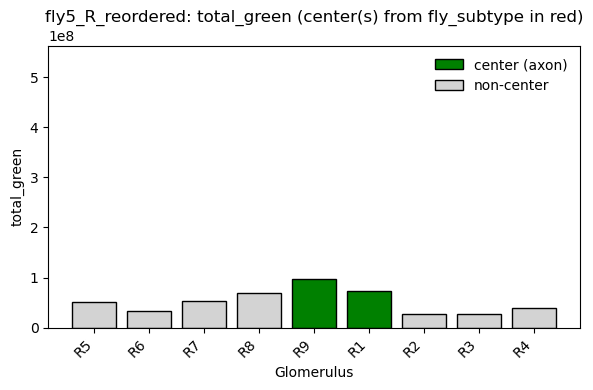

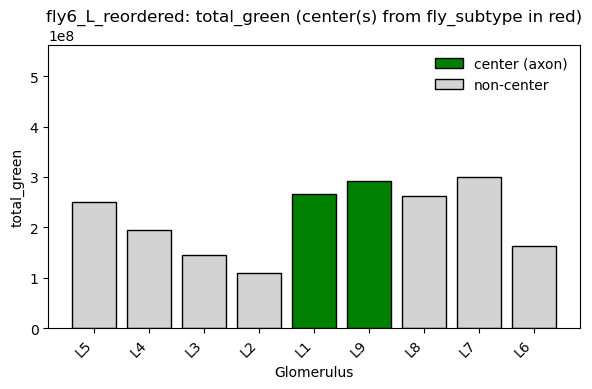

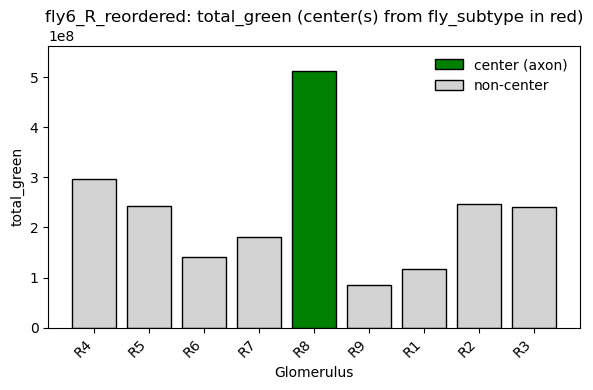

In [ ]:
# make the histograms of all halves
# this cell makes all the plots have the same y axis range!


# -----------------------
# Helpers / lookups
# -----------------------
def _is_present(x) -> bool:
    return isinstance(x, str) and x.strip() and x.strip().lower() != "none"

# Canonicalize labels like "PB(L3)" or " l3 " -> "L3"
def canon(s: object) -> str:
    s = str(s).strip().upper()
    m = re.search(r'[LR]\d+', s)
    return m.group(0) if m else s

# Ensure part3 exists (so code works for both 2- and 3-glo)
if "part3" not in fly_subtype.columns:
    fly_subtype = fly_subtype.assign(part3=np.nan)

# Fast lookup: {"fly1": {"part1": "...", "part2": "...", "part3": "..."}}
parts_lookup = fly_subtype.set_index("fly")[["part1", "part2", "part3"]].to_dict("index")

# -----------------------
# The missing function
# -----------------------
def get_centers_for_table(table_name: str) -> list[str]:
    """
    Return the list of center labels (e.g., ["L3"] or ["L1","L9"]) for a table name in
    `reordered_halves_all`. Works for both 2-glo and 3-glo based on fly_subtype.
    Table name format can be 'flyN_L', 'flyN_R', 'flyN_L_reordered', etc.
    """
    # Parse "<fly>_<side>" (side is final L/R before any extra suffixes)
    m = re.match(r'^(.+?)_([LR])(?:_.*)?$', table_name, flags=re.IGNORECASE)
    if not m:
        return []
    fly_base, side = m.group(1), m.group(2).upper()

    row = parts_lookup.get(fly_base)
    if row is None:
        return []

    p1, p2, p3 = row.get("part1"), row.get("part2"), row.get("part3")
    is_3glo = _is_present(p3)

    if not is_3glo:
        # ----- 2-glo logic -----
        if side == "L":
            center = p1 if _is_present(p1) else None
        else:
            center = p2 if _is_present(p2) else None
        return [center] if center else []

    # ----- 3-glo logic -----
    candidates = [p for p in (p1, p2, p3) if _is_present(p)]
    centers = [c.strip() for c in candidates if c.strip().upper().startswith(side)]
    return centers

# -----------------------
# Plot with shared y-axis
# -----------------------
# 1) find a common y max across all plots
global_max = 0.0
for _, df in reordered_halves_all.items():
    y = pd.to_numeric(df["total_green"], errors="coerce").fillna(0).to_numpy()
    if y.size:
        global_max = max(global_max, float(np.nanmax(y)))
ymax = global_max * 1.1 if global_max > 0 else 1.0  # margin

# 2) make each plot; color centers red after canonicalizing labels
for name, df in reordered_halves_all.items():
    centers_raw = get_centers_for_table(name)
    centers_set = {canon(c) for c in centers_raw if c is not None}

    gloms_raw = df["glomerulus"].astype(str).tolist()
    gloms_can = [canon(g) for g in gloms_raw]

    colors = ["green" if g in centers_set else "lightgray" for g in gloms_can]

    # Optional sanity check:
    # if "red" not in colors:
    #     print(f"[warn] no centers colored for {name}; centers={sorted(centers_set)}; gloms={gloms_can}")

    y = pd.to_numeric(df["total_green"], errors="coerce").fillna(0).to_numpy()

    plt.figure(figsize=(6, 4))
    plt.bar(gloms_raw, y, color=colors, edgecolor="black")
    plt.title(f"{name}: total_green")
    plt.xlabel("Glomerulus")
    plt.ylabel("total_green fluorescence")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, ymax)

    plt.legend(
        handles=[
            Patch(facecolor="green", edgecolor="black", label="axon"),
            Patch(facecolor="lightgray", edgecolor="black", label="dendrites"),
        ],
        loc="upper right",
        frameon=False,
    )
    
    plt.tight_layout()
    plt.show()

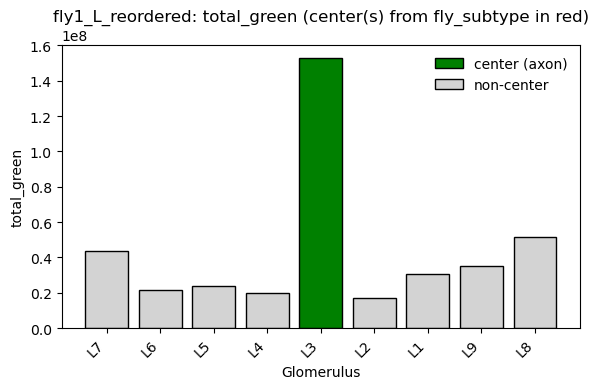

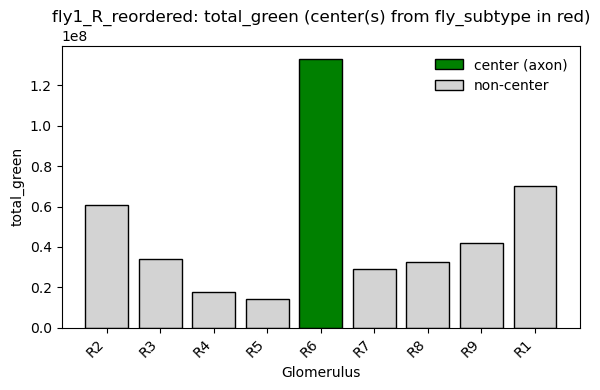

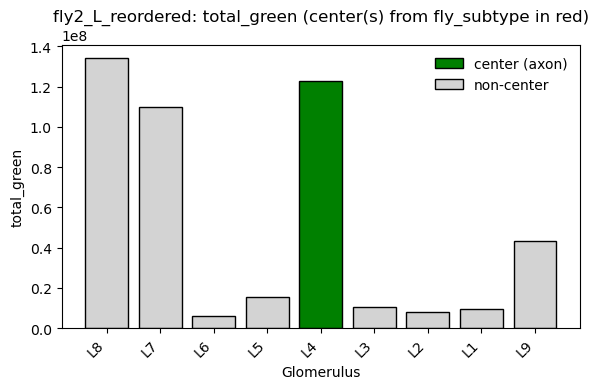

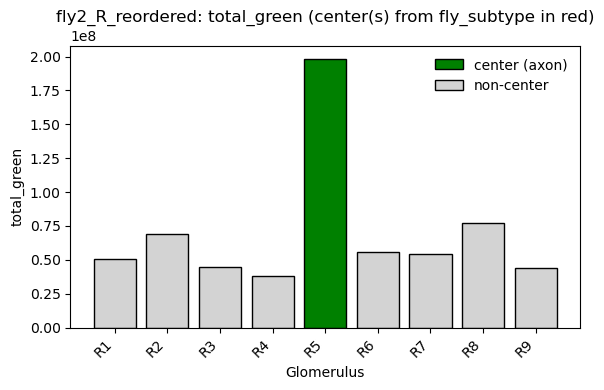

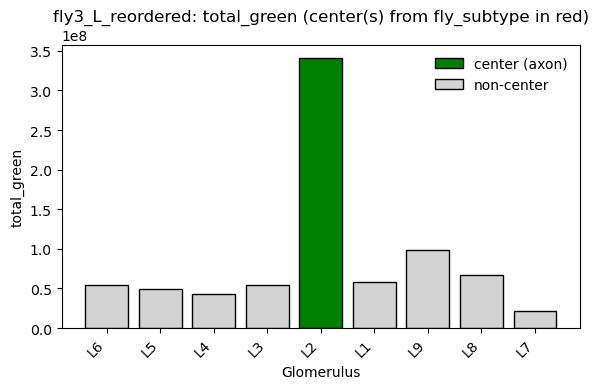

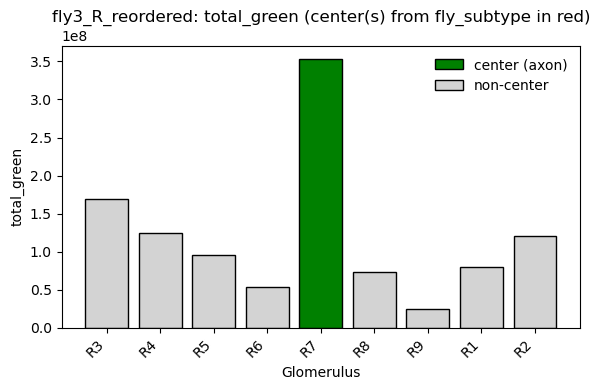

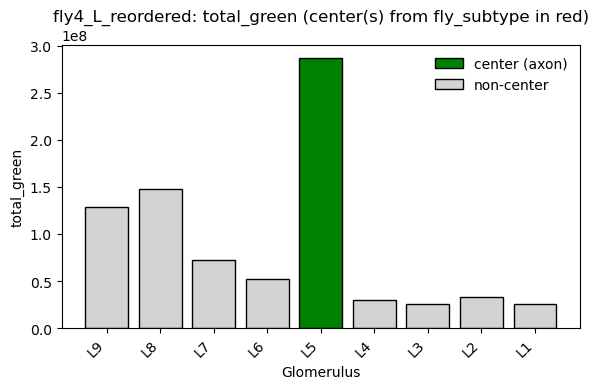

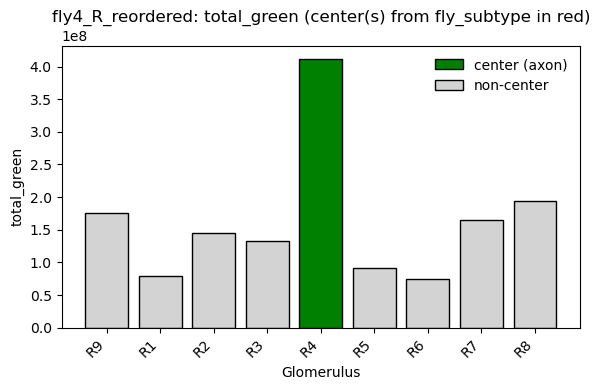

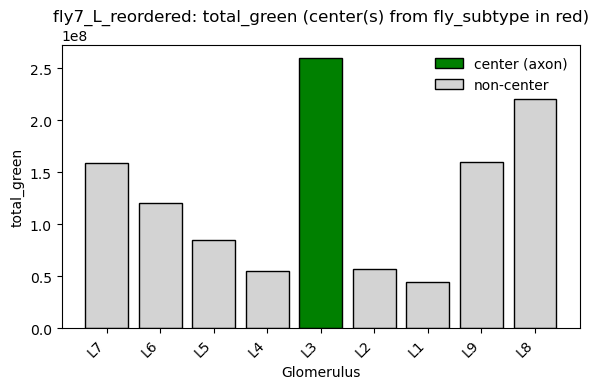

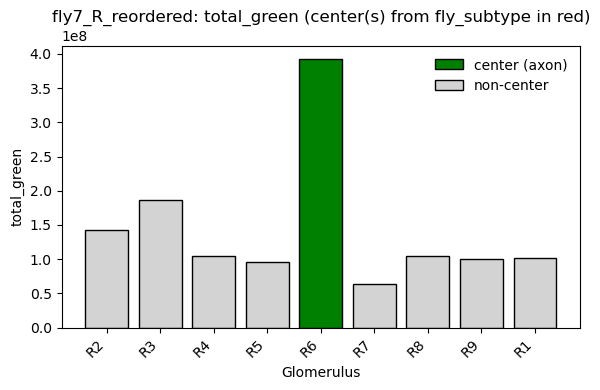

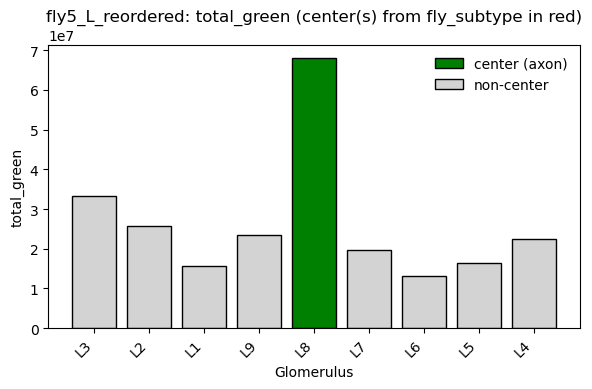

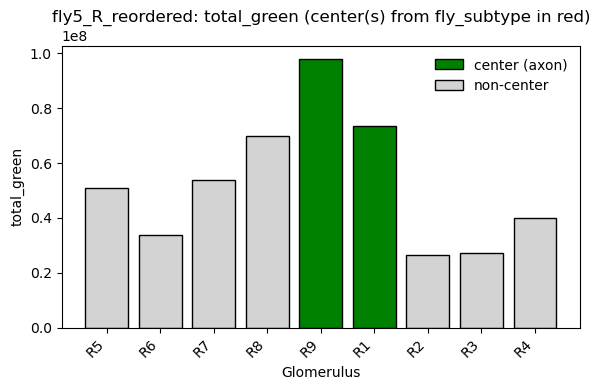

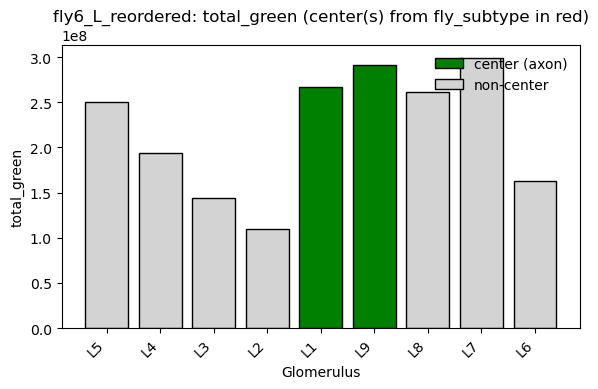

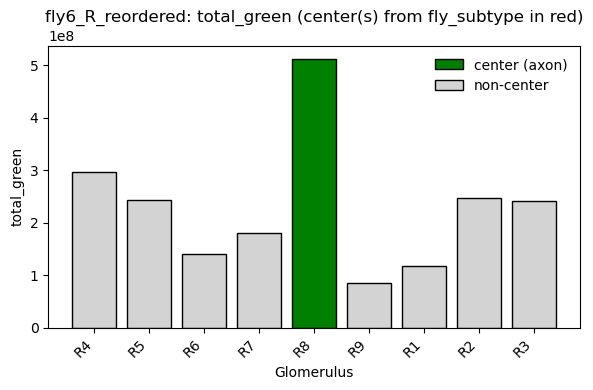

In [ ]:
# make the histograms of all halves
# this cell makes each plot have ITS OWN y axis range.

# -----------------------
# Helpers / lookups
# -----------------------
def _is_present(x) -> bool:
    return isinstance(x, str) and x.strip() and x.strip().lower() != "none"

# Canonicalize labels like "PB(L3)" or " l3 " -> "L3"
def canon(s: object) -> str:
    s = str(s).strip().upper()
    m = re.search(r'[LR]\d+', s)
    return m.group(0) if m else s

# Ensure part3 exists (so code works for both 2- and 3-glo)
if "part3" not in fly_subtype.columns:
    fly_subtype = fly_subtype.assign(part3=np.nan)

# Fast lookup: {"fly1": {"part1": "...", "part2": "...", "part3": "..."}}
parts_lookup = fly_subtype.set_index("fly")[["part1", "part2", "part3"]].to_dict("index")

# -----------------------
# The missing function
# -----------------------
def get_centers_for_table(table_name: str) -> list[str]:
    """
    Return the list of center labels (e.g., ["L3"] or ["L1","L9"]) for a table name in
    `reordered_halves_all`. Works for both 2-glo and 3-glo based on fly_subtype.
    Table name format can be 'flyN_L', 'flyN_R', 'flyN_L_reordered', etc.
    """
    # Parse "<fly>_<side>" (side is final L/R before any extra suffixes)
    m = re.match(r'^(.+?)_([LR])(?:_.*)?$', table_name, flags=re.IGNORECASE)
    if not m:
        return []
    fly_base, side = m.group(1), m.group(2).upper()

    row = parts_lookup.get(fly_base)
    if row is None:
        return []

    p1, p2, p3 = row.get("part1"), row.get("part2"), row.get("part3")
    is_3glo = _is_present(p3)

    if not is_3glo:
        # ----- 2-glo logic -----
        if side == "L":
            center = p1 if _is_present(p1) else None
        else:
            center = p2 if _is_present(p2) else None
        return [center] if center else []

    # ----- 3-glo logic -----
    candidates = [p for p in (p1, p2, p3) if _is_present(p)]
    centers = [c.strip() for c in candidates if c.strip().upper().startswith(side)]
    return centers

# -----------------------
# Plot (each plot can auto-scale its y-axis)
# -----------------------
for name, df in reordered_halves_all.items():
    centers_raw = get_centers_for_table(name)
    centers_set = {canon(c) for c in centers_raw if c is not None}

    gloms_raw = df["glomerulus"].astype(str).tolist()
    gloms_can = [canon(g) for g in gloms_raw]

    colors = ["green" if g in centers_set else "lightgray" for g in gloms_can]

    y = pd.to_numeric(df["total_green"], errors="coerce").fillna(0).to_numpy()

    plt.figure(figsize=(6, 4))
    plt.bar(gloms_raw, y, color=colors, edgecolor="black")
    plt.title(f"{name}: total_green")
    plt.xlabel("Glomerulus")
    plt.ylabel("total_green fluorescence")
    plt.xticks(rotation=45, ha="right")

    plt.legend(
        handles=[
            Patch(facecolor="green", edgecolor="black", label="axon"),
            Patch(facecolor="lightgray", edgecolor="black", label="dendrites"),
        ],
        loc="upper right",
        frameon=False,
    )
    
    plt.tight_layout()
    plt.show()

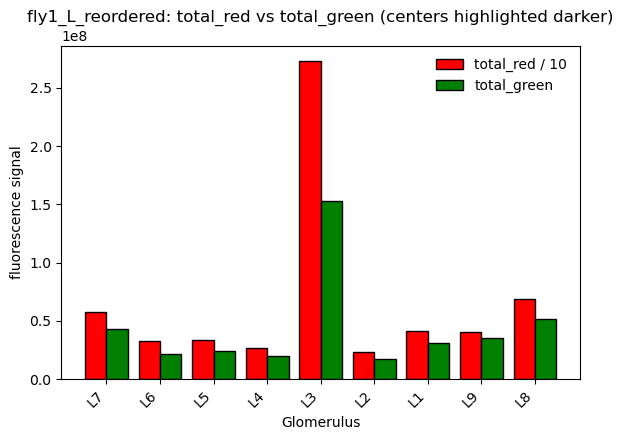

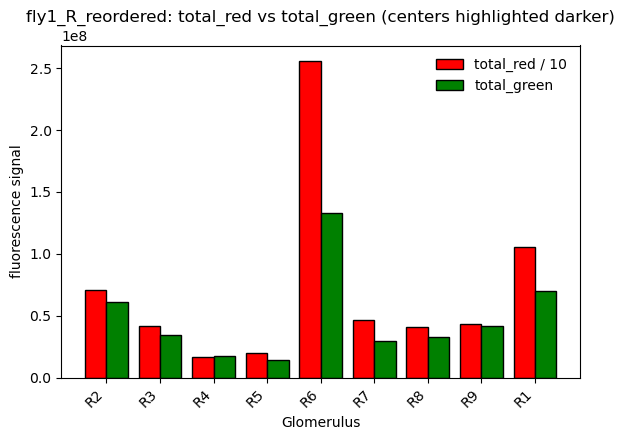

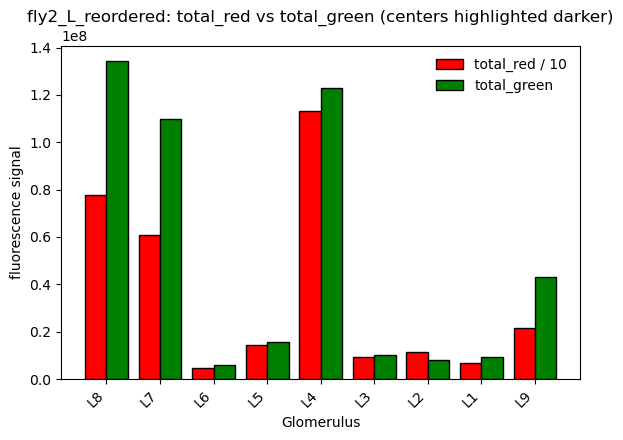

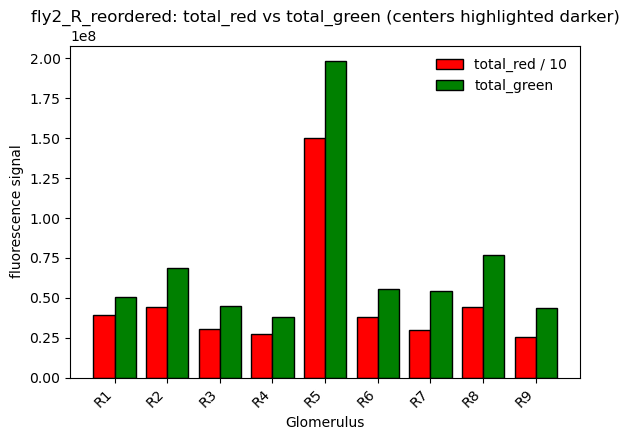

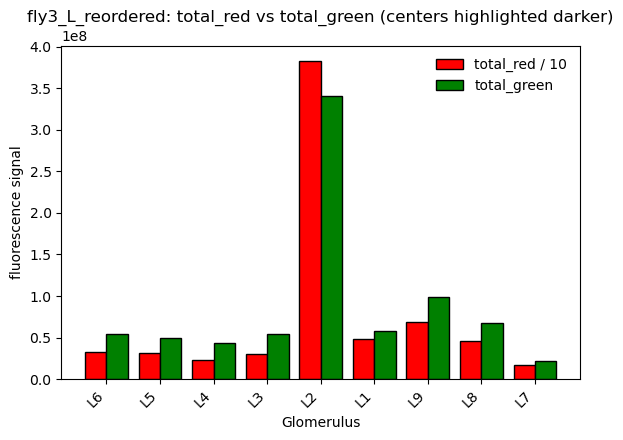

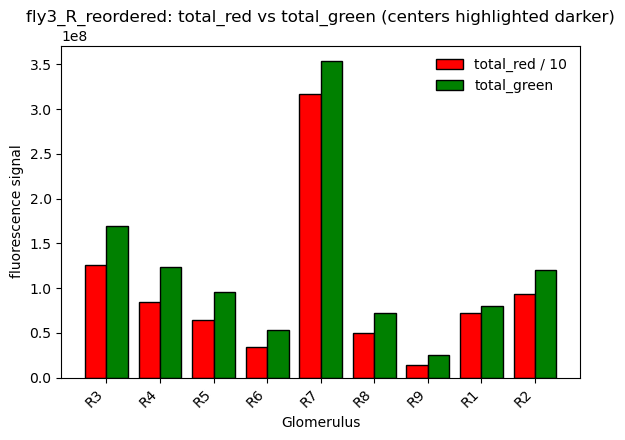

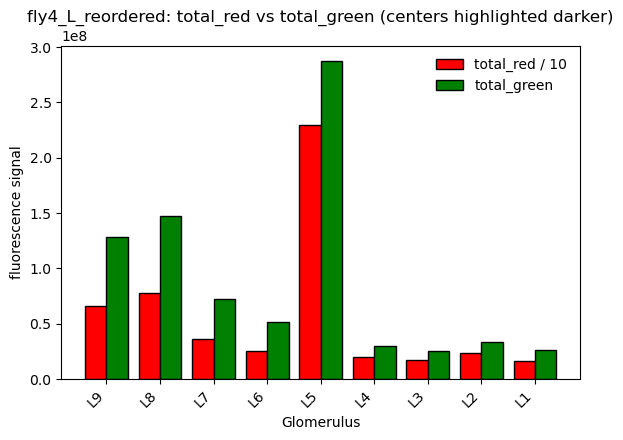

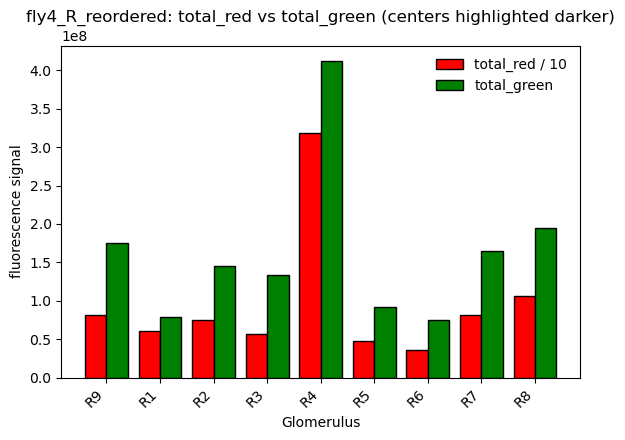

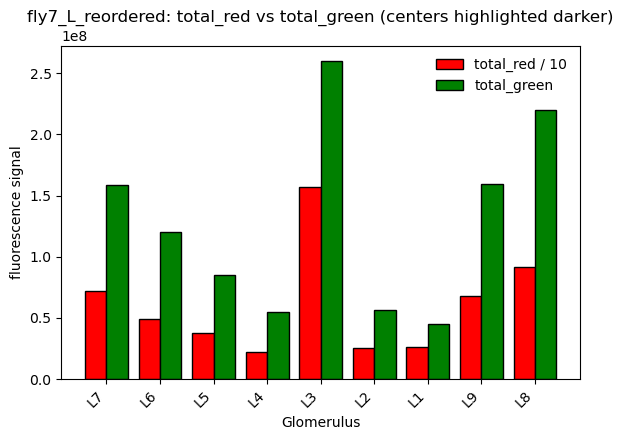

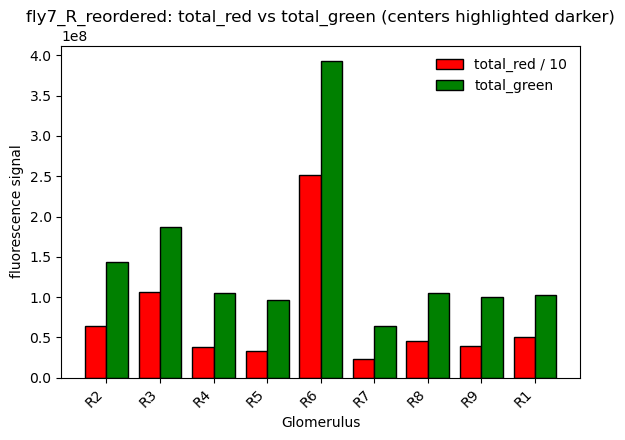

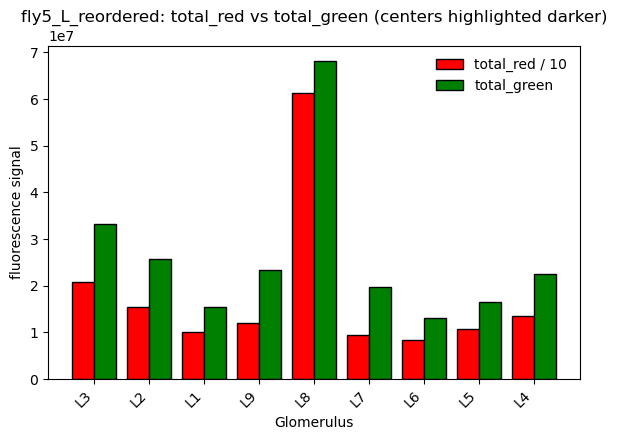

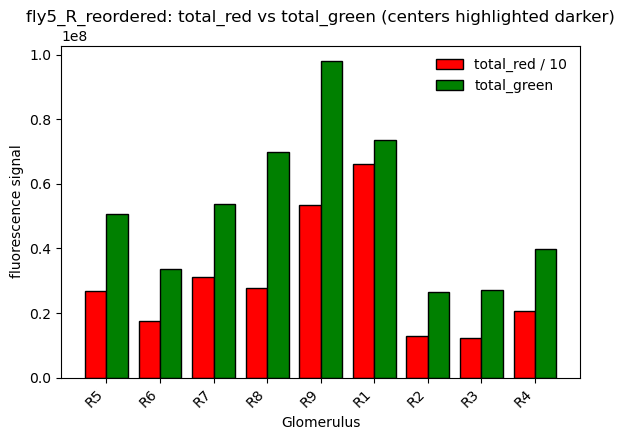

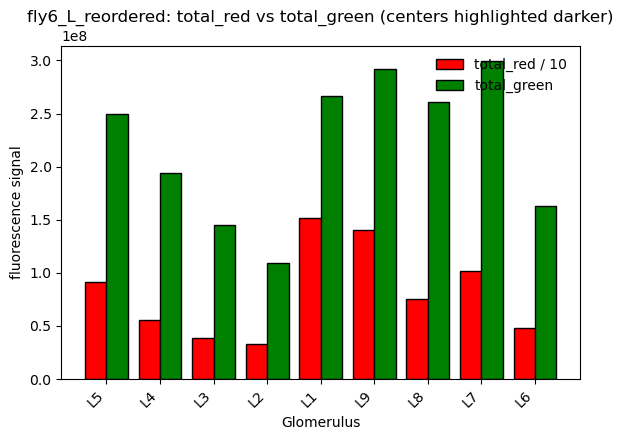

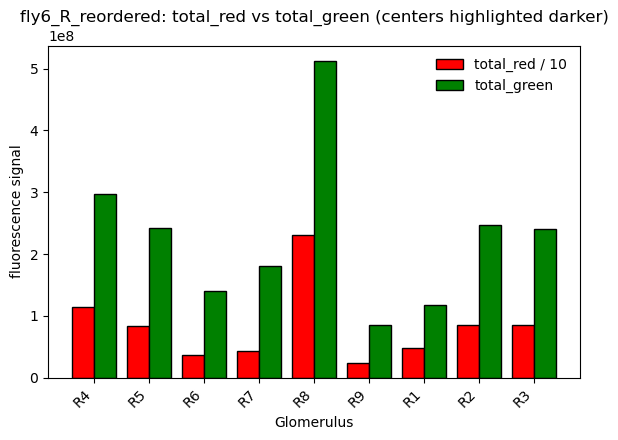

In [25]:
# -----------------------
# Helpers / lookups
# -----------------------
def _is_present(x) -> bool:
    return isinstance(x, str) and x.strip() and x.strip().lower() != "none"

def canon(s: object) -> str:
    """Canonicalize labels like 'PB(L3)' or ' l3 ' -> 'L3'"""
    s = str(s).strip().upper()
    m = re.search(r'[LR]\d+', s)
    return m.group(0) if m else s

if "part3" not in fly_subtype.columns:
    fly_subtype = fly_subtype.assign(part3=np.nan)

parts_lookup = fly_subtype.set_index("fly")[["part1", "part2", "part3"]].to_dict("index")

def get_centers_for_table(table_name: str) -> list[str]:
    """Return center labels for a table in reordered_halves_all."""
    m = re.match(r'^(.+?)_([LR])(?:_.*)?$', table_name, flags=re.IGNORECASE)
    if not m:
        return []
    fly_base, side = m.group(1), m.group(2).upper()

    row = parts_lookup.get(fly_base)
    if row is None:
        return []

    p1, p2, p3 = row.get("part1"), row.get("part2"), row.get("part3")
    is_3glo = _is_present(p3)

    if not is_3glo:  # 2-glo logic
        if side == "L":
            center = p1 if _is_present(p1) else None
        else:
            center = p2 if _is_present(p2) else None
        return [center] if center else []
    else:            # 3-glo logic
        candidates = [p for p in (p1, p2, p3) if _is_present(p)]
        centers = [c.strip() for c in candidates if c.strip().upper().startswith(side)]
        return centers

# -----------------------
# Plot with two bars per glomerulus
# -----------------------
red_scale = 10  # scale down red values if needed

for name, df in reordered_halves_all.items():
    centers_raw = get_centers_for_table(name)
    centers_set = {canon(c) for c in centers_raw if c is not None}

    gloms_raw = df["glomerulus"].astype(str).tolist()
    gloms_can = [canon(g) for g in gloms_raw]

    y_green = pd.to_numeric(df["total_green"], errors="coerce").fillna(0).to_numpy()
    y_red   = pd.to_numeric(df["total_red"],   errors="coerce").fillna(0).to_numpy() / red_scale

    idx = np.arange(len(gloms_raw))
    bar_width = 0.4

    # Assign colors: all red/green, but darker if center
    #colors_red   = ["darkred"   if g in centers_set else "red"   for g in gloms_can]
    #colors_green = ["darkgreen" if g in centers_set else "green" for g in gloms_can]
    colors_red   = ["red"]
    colors_green = ["green"]

    plt.figure(figsize=(6, 4.5))

    plt.bar(idx - bar_width/2, y_red,   width=bar_width, color=colors_red,   edgecolor="black", label=f"total_red / {red_scale}")
    plt.bar(idx + bar_width/2, y_green, width=bar_width, color=colors_green, edgecolor="black", label="total_green")

    plt.title(f"{name}: total_red vs total_green (centers highlighted darker)")
    plt.xlabel("Glomerulus")
    plt.ylabel("fluorescence signal")
    plt.xticks(idx, gloms_raw, rotation=45, ha="right")

    plt.legend(loc="upper right", frameon=False)
    plt.tight_layout()
    plt.show()

<font size="7">PART THREE</font>

1. put the sides that only has one axon glomerulus into one dict [reordered_2glo_some3glo_halves], and put the rest sides into [reordered_weird3glo_halves].
2. sum (and average) all the df in [reordered_2glo_some3glo_halves] into one df "sum_2glo_some3glo_halves", and then make bar graph.
3. first, combine the 1 and 9 glomerulus by summing and then averaging the 2 rows, and store the new df into [reordered_weird3glo_halves_1and9combined]. Then, sum (and average) all the df in this dict into one df "sum_weird3glo_1and9combined", and then make bar graph.

In [26]:
# create a dict [reordered_2glo_some3glo_halves] that excludes the L1L9 and R1R9 side of the 3 glo brains and includes everything else.

# Start with all 2-glo halves
reordered_2glo_some3glo_halves = dict(reordered_2glo_halves)

for name, df in reordered_3glo_halves.items():
    # extract base fly name and side (L/R)
    m = re.match(r"^(.+?)_([LR])(?:_.*)?$", name, flags=re.IGNORECASE)
    if not m:
        continue
    fly_base, side = m.group(1), m.group(2).upper()                     # m.group(1) is fly*, m.group(2) is L or R.

    # get the row for this fly in fly_subtype
    if fly_base not in fly_subtype["fly"].values:
        continue
    row = fly_subtype.loc[fly_subtype["fly"] == fly_base].iloc[0]       # row extract all the parts of this fly*

    # collect non-empty parts
    parts = [row.get("part1"), row.get("part2"), row.get("part3")]
    valid_parts = [str(p).strip().upper() for p in parts if isinstance(p, str) and p.strip().lower() != "none"] # a list of all parts of this fly*. eg. ['L1', 'L9', 'R8']

    # filter by side (e.g. "L3" startswith "L")
    side_parts = [p for p in valid_parts if p.startswith(side)]         # if side is L, then side_parts=['L1', 'L9']; if side is R, then side_parts=['R8'] for a 3glo brain.

    # rule: add only if exactly 1 matching part
    if len(side_parts) == 1:
        reordered_2glo_some3glo_halves[name] = df
    # else: skip (more than one match)

In [28]:
list(reordered_2glo_some3glo_halves.keys())

['fly1_L_reordered',
 'fly1_R_reordered',
 'fly2_L_reordered',
 'fly2_R_reordered',
 'fly3_L_reordered',
 'fly3_R_reordered',
 'fly4_L_reordered',
 'fly4_R_reordered',
 'fly7_L_reordered',
 'fly7_R_reordered',
 'fly5_L_reordered',
 'fly6_R_reordered']

In [29]:
# create a dict [reordered_weird3glo_halves] that has everything else not included in [reordered_2glo_some3glo_halves]

reordered_weird3glo_halves = {
    name: df
    for name, df in reordered_3glo_halves.items()
    if name not in reordered_2glo_some3glo_halves
}
list(reordered_weird3glo_halves.keys())

['fly5_R_reordered', 'fly6_L_reordered']

In [30]:
reordered_weird3glo_halves['fly5_R_reordered']

,glomerulus,mean_red,mean_green,total_red,total_green
0,R5,141.105013,26.666706,268482061,50739034
1,R6,153.156412,29.188990,176626254,33661940
2,R7,205.923968,35.560629,311569965,53804440
3,R8,146.704492,36.782444,278433829,69810246
4,R9,239.888989,40.622732,535220205,97960443
5,R1,234.183041,26.001336,662037565,73506012
6,R2,105.323247,21.642499,128691526,26444363
7,R3,106.027822,23.489537,123137319,27279997
8,R4,126.859500,24.551414,205863156,39841176


folder = "reordered_2glo_some3glo_halves"
os.makedirs(folder, exist_ok=True)  # create folder if not already there

# save each df
for name, df in reordered_2glo_some3glo_halves.items():
    filename = os.path.join(folder, f"{name}.csv")
    df.to_csv(filename, index=False)

print(f"Saved {len(reordered_2glo_some3glo_halves)} files into '{folder}/'")

In [ ]:
# sum and avg the distributions from [reordered_2glo_some3glo_halves]

# columns to sum
cols = ["mean_red", "mean_green", "total_red", "total_green"]

# collect cleaned 9-row numeric slices from every df
stack = []
for name, df in reordered_2glo_some3glo_halves.items():
    tmp = (
        df[cols]
        .apply(pd.to_numeric, errors="coerce")   # ensure numeric
        .reset_index(drop=True)                  # 0..8
        .reindex(range(9))                       # force 9 rows
        .fillna(0)
    )
    stack.append(tmp)

n_inputs = len(stack)

if n_inputs == 0:
    sum_2glo_some3glo_halves = pd.DataFrame(0, index=range(9), columns=cols)
else:
    sum_2glo_some3glo_halves = (                                                                            # concat function: stack all the DataFrames into one big DataFrame. Each gets a key (0,1,2,…). Result has a MultiIndex: outer level = key, inner level = row index 0..8.
        pd.concat(stack, keys=range(n_inputs))
          .groupby(level=1)
          .sum()                                                                                            # sum each group row-wise across all inputs.
    )

# add the position column on the left: -4..4
sum_2glo_some3glo_halves.insert(0, "glomerulus", list(range(-4, 5)))                                        # the first 0 is the position of the column that is going to be added.

# add averages (per-position mean across input DataFrames)
if n_inputs > 0:
    sum_2glo_some3glo_halves["total_red_avg"]   = sum_2glo_some3glo_halves["total_red"]   / n_inputs
    sum_2glo_some3glo_halves["total_green_avg"] = sum_2glo_some3glo_halves["total_green"] / n_inputs
    sum_2glo_some3glo_halves["mean_red_avg"]   = sum_2glo_some3glo_halves["mean_red"]   / n_inputs
    sum_2glo_some3glo_halves["mean_green_avg"] = sum_2glo_some3glo_halves["mean_green"] / n_inputs
else:
    # no inputs -> keep NaNs for clarity (or set to 0 if you prefer)
    sum_2glo_some3glo_halves["total_red_avg"]   = np.nan
    sum_2glo_some3glo_halves["total_green_avg"] = np.nan

sum_2glo_some3glo_halves

,glomerulus,mean_red,mean_green,total_red,total_green,total_red_avg,total_green_avg,mean_red_avg,mean_green_avg
0,-4,8950.032367,1511.256995,8.216967e+09,1.449562e+09,6.847473e+08,1.207968e+08,745.836031,125.938083
1,-3,8314.715903,1317.017621,6.884148e+09,1.209767e+09,5.736790e+08,1.008139e+08,692.892992,109.751468
2,-2,7253.198984,1289.591727,4.056502e+09,7.942974e+08,3.380418e+08,6.619145e+07,604.433249,107.465977
3,-1,7273.672706,1319.075667,3.446484e+09,7.344644e+08,2.872070e+08,6.120537e+07,606.139392,109.922972
4,0,14205.878756,1646.781885,2.740131e+10,3.232123e+09,2.283443e+09,2.693436e+08,1183.823230,137.231824
5,1,7603.940112,1205.351235,3.642938e+09,5.906427e+08,3.035782e+08,4.922022e+07,633.661676,100.445936
6,2,7793.283542,1218.413641,3.877420e+09,6.291371e+08,3.231184e+08,5.242809e+07,649.440295,101.534470
7,3,8523.583083,1390.356298,5.598599e+09,1.031374e+09,4.665499e+08,8.594782e+07,710.298590,115.863025
8,4,8793.824228,1397.550449,6.942441e+09,1.155783e+09,5.785367e+08,9.631529e+07,732.818686,116.462537


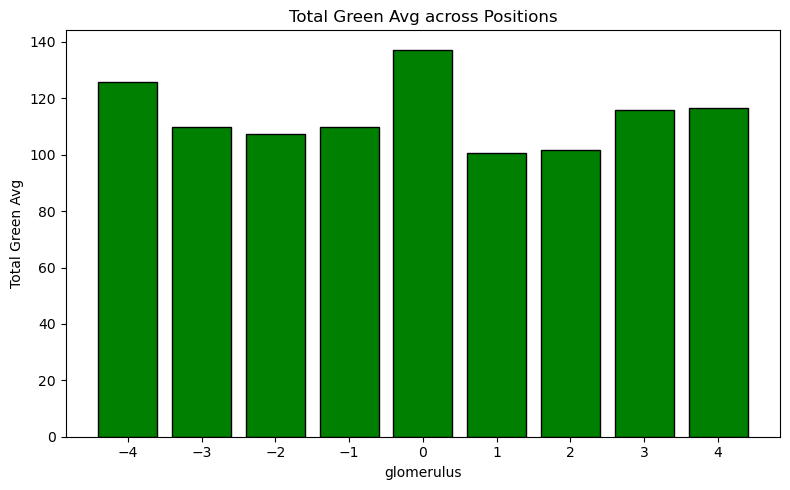

In [65]:
df = sum_2glo_some3glo_halves.copy()

plt.figure(figsize=(8, 5))

# plot bars
plt.bar(df["glomerulus"], df["mean_green_avg"], color="green", edgecolor="black")

# labels and title
plt.xlabel("glomerulus")
plt.ylabel("Total Green Avg")
plt.title("Total Green Avg across Positions")

# ensure all positions appear on x-axis
plt.xticks(df["glomerulus"])

plt.tight_layout()
plt.show()

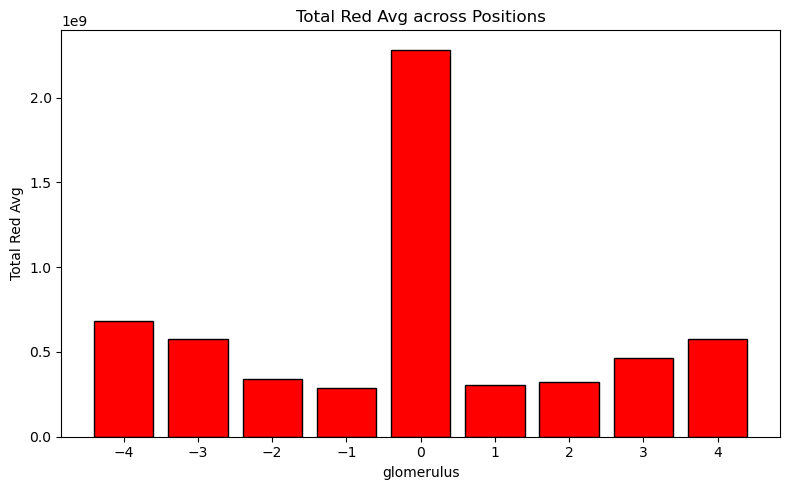

In [56]:
df = sum_2glo_some3glo_halves.copy()

plt.figure(figsize=(8, 5))

# plot bars
plt.bar(df["glomerulus"], df["total_red_avg"], color="red", edgecolor="black")

# labels and title
plt.xlabel("glomerulus")
plt.ylabel("Total Red Avg")
plt.title("Total Red Avg across Positions")

# ensure all positions appear on x-axis
plt.xticks(df["glomerulus"])

plt.tight_layout()
plt.show()

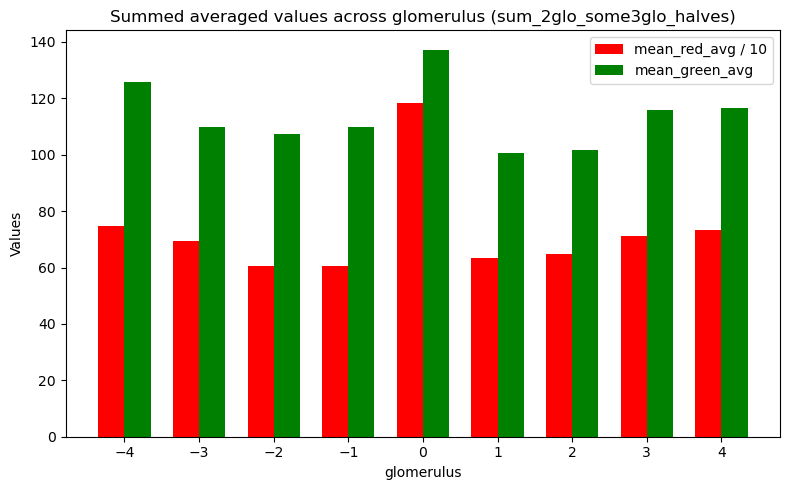

In [66]:
df = sum_2glo_some3glo_halves.copy()

# positions (x-axis)
x = df["glomerulus"].to_numpy()
bar_width = 0.35   # wider bars since only 2 series

# columns to plot
cols = ["total_green_avg", "total_red_avg"]

plt.figure(figsize=(8, 5))

# red series (scaled down by 10)
plt.bar(
    x - bar_width/2,         # shift left
    df["mean_red_avg"] / 10,                       # divided the total_red_avg by 10 just so it can be compared side-by-side to total_green_avg
    width=bar_width,
    label="mean_red_avg / 10",
    color="red"
)

# green series (no scaling)
plt.bar(
    x + bar_width/2,         # shift right
    df["mean_green_avg"],
    width=bar_width,
    label="mean_green_avg",
    color="green"
)

plt.xlabel("glomerulus")
plt.ylabel("Values")
plt.title("Summed averaged values across glomerulus (sum_2glo_some3glo_halves)")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# this cell plots both the individual data (in thin grey lines) and the population data (in colored thicker line).


def plot_individual_vs_population(indiv_dict, pop_df, metric="mean", channel="green", line_color=None):
    """
    Plot all individual data (thin gray lines) and the population average (thick colored line).

    indiv_dict : dict of DataFrames
        Each DataFrame must contain a column named f"{metric}_{channel}".
    pop_df : DataFrame
        Must contain columns f"{metric}_{channel}" and f"{metric}_{channel}_avg".
    metric : str, default "mean"
        The metric to use ("mean" or "total").
    channel : str, default "green"
        The channel name ("green" or "red").
    line_color : str, optional
        Color for the population line. If None, use the channel name.
    """
    signal = f"{metric}_{channel}"
    signal_avg = f"{metric}_{channel}_avg"
    line_color = line_color or channel  # default: "green" -> green line, "red" -> red line

    # lengths
    lens = [len(df) for df in indiv_dict.values()]
    lens.append(len(pop_df))
    L = min(lens)  # common length

    x = np.arange(L)

    plt.figure(figsize=(7, 5))

    # thin lines for individuals
    for name, df in indiv_dict.items():
        y = pd.to_numeric(df[signal], errors="coerce").to_numpy()[:L]
        plt.plot(x, y, linewidth=1, alpha=0.45, color="gray")

    # proxy line for legend (Adds a legend entry without drawing a real line on the axes)
    plt.plot([], [], linewidth=1, color="gray", alpha=0.6, label=f"individuals ({signal})")

    # population line
    y_pop = pd.to_numeric(pop_df[signal_avg], errors="coerce").to_numpy()[:L]
    plt.plot(x, y_pop, linewidth=4, color=line_color, marker="o", label=f"population ({signal_avg})")

    # x-axis labels
    if "glomerulus" in pop_df.columns:
        xtick_labels = pop_df["glomerulus"].astype(str).tolist()[:L]
    else:
        xtick_labels = [str(i) for i in range(L)]

    plt.xticks(x, xtick_labels, rotation=45, ha="right")
    plt.xlabel("Glomerulus")
    plt.ylabel(signal.replace("_", " "))
    plt.title(f"Individuals (thin) vs Population (thick) (n={len(indiv_dict)})")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

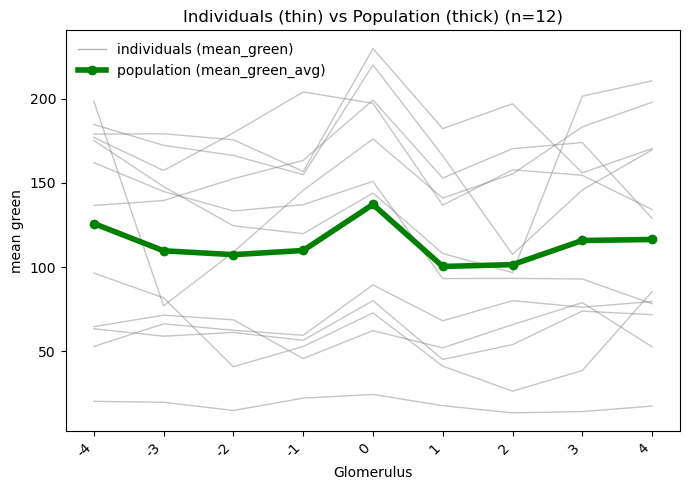

In [64]:
# this cell plots both the individual data (in thin grey lines) and the population data (in colored thicker line).


pop_df = sum_2glo_some3glo_halves

plot_individual_vs_population(reordered_2glo_some3glo_halves, pop_df, 'mean', 'green')

In [95]:
sum_2glo_some3glo_halves

,glomerulus,mean_red,mean_green,total_red,total_green,total_red_avg,total_green_avg,mean_red_avg,mean_green_avg
0,-4,8950.032367,1511.256995,8.216967e+09,1.449562e+09,6.847473e+08,1.207968e+08,745.836031,125.938083
1,-3,8314.715903,1317.017621,6.884148e+09,1.209767e+09,5.736790e+08,1.008139e+08,692.892992,109.751468
2,-2,7253.198984,1289.591727,4.056502e+09,7.942974e+08,3.380418e+08,6.619145e+07,604.433249,107.465977
3,-1,7273.672706,1319.075667,3.446484e+09,7.344644e+08,2.872070e+08,6.120537e+07,606.139392,109.922972
4,0,14205.878756,1646.781885,2.740131e+10,3.232123e+09,2.283443e+09,2.693436e+08,1183.823230,137.231824
5,1,7603.940112,1205.351235,3.642938e+09,5.906427e+08,3.035782e+08,4.922022e+07,633.661676,100.445936
6,2,7793.283542,1218.413641,3.877420e+09,6.291371e+08,3.231184e+08,5.242809e+07,649.440295,101.534470
7,3,8523.583083,1390.356298,5.598599e+09,1.031374e+09,4.665499e+08,8.594782e+07,710.298590,115.863025
8,4,8793.824228,1397.550449,6.942441e+09,1.155783e+09,5.785367e+08,9.631529e+07,732.818686,116.462537


# below deals with 3glo brains...

In [ ]:
# for the [reordered_weird3glo_halves], first combine glomerulus 1 and 9: yvette said i should just add 1 and 9 up, no averaging.
# so i sum the "total_red" and "total_green" column, but kept the mean in "mean_red" and "mean_green" (since they are means...)

# numeric columns
num_cols = ["mean_red", "mean_green", "total_red", "total_green"]

reordered_weird3glo_halves_1and9combined = {}

for name, df in reordered_weird3glo_halves.items():
    d = df.copy().reset_index(drop=True)

    # need at least rows 0..5 present
    if len(d) < 6:
        continue

    # convert numeric cols safely
    numeric_block = d.loc[[4, 5], num_cols].apply(pd.to_numeric, errors="coerce")

    # sum totals
    summed_vals = numeric_block[["total_red", "total_green"]].sum(axis=0, skipna=True)

    # mean of means
    mean_vals = numeric_block[["mean_red", "mean_green"]].mean(axis=0, skipna=True)

    # assign back
    d.loc[4, "total_red"]   = summed_vals["total_red"]
    d.loc[4, "total_green"] = summed_vals["total_green"]
    d.loc[4, "mean_red"]    = mean_vals["mean_red"]
    d.loc[4, "mean_green"]  = mean_vals["mean_green"]

    # drop original row 5 and shift remaining rows up
    d = d.drop(index=5).reset_index(drop=True)

    if "glomerulus" in d.columns and len(d) > 5:
        d.at[4, "glomerulus"] = "axon"

    # save with requested name
    new_name = f"{name}_1&9combined"
    reordered_weird3glo_halves_1and9combined[new_name] = d

list(reordered_weird3glo_halves_1and9combined.keys())

['fly5_R_reordered_1&9combined', 'fly6_L_reordered_1&9combined']

In [38]:
reordered_weird3glo_halves['fly5_R_reordered']

,glomerulus,mean_red,mean_green,total_red,total_green
0,R5,141.105013,26.666706,268482061,50739034
1,R6,153.156412,29.188990,176626254,33661940
2,R7,205.923968,35.560629,311569965,53804440
3,R8,146.704492,36.782444,278433829,69810246
4,R9,239.888989,40.622732,535220205,97960443
5,R1,234.183041,26.001336,662037565,73506012
6,R2,105.323247,21.642499,128691526,26444363
7,R3,106.027822,23.489537,123137319,27279997
8,R4,126.859500,24.551414,205863156,39841176


In [39]:
reordered_weird3glo_halves['fly6_L_reordered']

,glomerulus,mean_red,mean_green,total_red,total_green
0,L5,582.474425,159.246668,9.140422e+08,249896241.0
1,L4,431.326973,152.045308,5.514071e+08,194374265.0
2,L3,360.642758,134.124884,3.887624e+08,144582735.0
3,L2,312.708269,104.127724,3.294169e+08,109691477.0
4,L1,811.562076,143.245844,1.511680e+09,266821168.0
5,L9,979.079773,203.910521,1.399893e+09,291552283.0
6,L8,463.568323,161.377641,7.504833e+08,261258620.0
7,L7,568.878374,167.711272,1.014467e+09,299075486.0
8,L6,423.130145,143.014581,4.827564e+08,163167767.0


In [47]:
reordered_weird3glo_halves_1and9combined['fly5_R_reordered_1&9combined']

,glomerulus,mean_red,mean_green,total_red,total_green
0,R5,141.105013,26.666706,268482061,50739034
1,R6,153.156412,29.188990,176626254,33661940
2,R7,205.923968,35.560629,311569965,53804440
3,R8,146.704492,36.782444,278433829,69810246
4,axon,237.036015,33.312034,1197257770,171466455
5,R2,105.323247,21.642499,128691526,26444363
6,R3,106.027822,23.489537,123137319,27279997
7,R4,126.859500,24.551414,205863156,39841176


In [48]:
reordered_weird3glo_halves_1and9combined['fly6_L_reordered_1&9combined']

,glomerulus,mean_red,mean_green,total_red,total_green
0,L5,582.474425,159.246668,9.140422e+08,249896241.0
1,L4,431.326973,152.045308,5.514071e+08,194374265.0
2,L3,360.642758,134.124884,3.887624e+08,144582735.0
3,L2,312.708269,104.127724,3.294169e+08,109691477.0
4,axon,895.320925,173.578182,2.911574e+09,558373451.0
5,L8,463.568323,161.377641,7.504833e+08,261258620.0
6,L7,568.878374,167.711272,1.014467e+09,299075486.0
7,L6,423.130145,143.014581,4.827564e+08,163167767.0


In [49]:
# sum and avg the distributions from [reordered_weird3glo_halves_1and9combined]: L1L9 and R1R9 sides that have their glomerulus 1 and 9 combined and averaged.


# columns to sum
cols = ["mean_red", "mean_green", "total_red", "total_green"]

stack = []
for name, df in reordered_weird3glo_halves_1and9combined.items():
    tmp = (
        df[cols]
        .apply(pd.to_numeric, errors="coerce")   # ensure numeric
        .reset_index(drop=True)                  # 0..7
        .reindex(range(8))                       # force 8 rows
        .fillna(0)
    )
    stack.append(tmp)

n_inputs = len(stack)

if n_inputs == 0:
    sum_weird3glo_1and9combined = pd.DataFrame(0, index=range(8), columns=cols)
else:
    sum_weird3glo_1and9combined = (
        pd.concat(stack, keys=range(n_inputs))
          .groupby(level=1)
          .sum()
    )

# add the position column on the left: now length 8
# you can decide what the positions should be. For example:
positions = [-4, -3, -2, -1, 0, 1, 2, 3]   # 8 slots

sum_weird3glo_1and9combined.insert(0, "position", positions)

# add averages (per-position mean across input DataFrames)
if n_inputs > 0:
    sum_weird3glo_1and9combined["total_red_avg"]   = sum_weird3glo_1and9combined["total_red"]   / n_inputs
    sum_weird3glo_1and9combined["total_green_avg"] = sum_weird3glo_1and9combined["total_green"] / n_inputs
else:
    sum_weird3glo_1and9combined["total_red_avg"]   = np.nan
    sum_weird3glo_1and9combined["total_green_avg"] = np.nan

In [50]:
sum_weird3glo_1and9combined

,position,mean_red,mean_green,total_red,total_green,total_red_avg,total_green_avg
0,-4,723.579438,185.913374,1.182524e+09,300635275.0,5.912621e+08,150317637.5
1,-3,584.483385,181.234298,7.280334e+08,228036205.0,3.640167e+08,114018102.5
2,-2,566.566726,169.685513,7.003324e+08,198387175.0,3.501662e+08,99193587.5
3,-1,459.412761,140.910168,6.078507e+08,179501723.0,3.039254e+08,89750861.5
4,0,1132.356940,206.890216,4.108831e+09,729839906.0,2.054416e+09,364919953.0
5,1,568.891570,183.020140,8.791748e+08,287702983.0,4.395874e+08,143851491.5
6,2,674.906196,191.200809,1.137604e+09,326355483.0,5.688022e+08,163177741.5
7,3,549.989645,167.565995,6.886195e+08,203008943.0,3.443098e+08,101504471.5


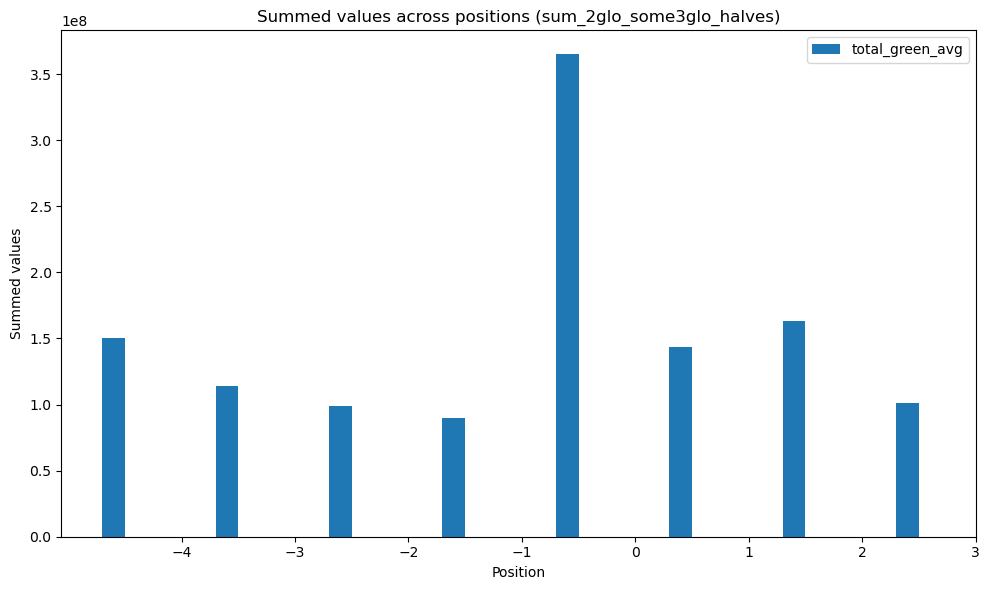

In [ ]:
df = sum_weird3glo_1and9combined.copy()

# positions (x-axis)
x = df["position"].to_numpy()
bar_width = 0.2

# offsets for multiple bars
offsets = np.arange(-(len(df.columns)-1)/2, (len(df.columns)-1)/2 + 1) * bar_width

# columns to plot (skip the "position" column)
cols = ["total_green_avg"]

plt.figure(figsize=(10, 6))

for i, col in enumerate(cols):
    plt.bar(x + offsets[i], df[col], width=bar_width, label=col)

plt.xlabel("Position")
plt.ylabel("Summed values")
plt.title("Summed values across positions (sum_weird3glo_1and9combined)")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()

# codes that i used but now no longer use...

# split left and right bridge for 3glo brains:


parts_lookup = fly_subtype.set_index("fly")[["part1", "part2", "part3"]].to_dict("index")

reordered_3glo_halves = {}  # output for 3-glom brains

for name, df in brains_with_3glo_halves.items():
    # parse fly base name and side ("_L" or "_R" at the end is assumed)
    if "_" not in name:
        continue
    fly_base, side = name.rsplit("_", 1)            # fly1_L --> L
    side = side.upper()
    if side not in {"L", "R"}:
        continue

    # lookup this fly’s parts
    parts = parts_lookup.get(fly_base)              # makes a dictionary for this fly* {'part1': 'L3', 'part2': 'R6', 'part3': None} where "part*" is the key.
    if parts is None:
        continue

    # 2) collect all centers that match the side (L or R) across part1/part2/part3
    raw_parts = [parts.get("part1"), parts.get("part2"), parts.get("part3")]
    centers = []
    for p in raw_parts:
        if isinstance(p, str):
            s = p.strip()                           # just remove any blankspace
            if s and s.lower() != "none" and s.upper().startswith(side):
                centers.append(s)

    if not centers:
        # nothing to center on
        continue

    # 3) preference rule when two centers exist:
    #    prefer "<side>1" over "<side>9" (i.e., L1 over L9, R1 over R9).
    preferred = None
    if (side + "1") in centers:
        preferred = side + "1"
    elif (side + "9") in centers:
        preferred = side + "9"
    else:
        # if neither specific preference is present, just take the first
        preferred = centers[0]

    center = preferred  # the label we will align to row 5 (index 4)

    # find the current index of the chosen center in this half
    idxs = df.index[df["glomerulus"].astype(str) == center]
    if len(idxs) == 0:
        # if the label isn't present in this half, skip
        continue
    current_idx = int(idxs[0])

    # place center on the 5th row (0-based index 4)
    target_idx = 4
    shift = target_idx - current_idx

    # roll row order safely (preserve columns/dtypes)
    order = np.roll(np.arange(len(df)), shift)
    df_reordered = df.iloc[order].reset_index(drop=True)

    reordered_3glo_halves[f"{name}_reordered"] = df_reordered